# Multimodal Cardiac Fusion Model V4 — ECG + Echocardiogram
**Task:** 5-class structural disease + 5-class arrhythmia classification (multi-task)
**Architecture:** 1D-ResNet (ECG) → Phase Tokenizer + ResNet50 (Echo) → Cycle Tokenizer → Shared Bidirectional Cross-Attention → Task-Aware Asymmetric Gated Readouts → 2× MLP Heads
**Training:** 3-stage curriculum — (1) frozen encoders, (2) frozen echo backbone, (3) full fine-tuning
**Data:** preprocessed with V3 pipeline (minimal echo crop, NaN-safe ECG, 5-class labels)

## 0 · Environment Check

In [1]:
import torch

print(f"PyTorch   : {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {props.total_memory / 1e9:.1f} GB")
    print(f"VRAM free : {(props.total_memory - torch.cuda.memory_reserved(0)) / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")

PyTorch   : 2.11.0+cu128
CUDA avail: True
GPU       : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM      : 8.6 GB
VRAM free : 8.6 GB

Using device: cuda


## 1 · Configuration

**Architecture tuning for ~3200 samples:**
- ECG Transformer reduced to 1 layer (from 2) and seq_len=32 (from 64) — cuts ~800K trainable params
- PROJ_DIM kept at 256 for sufficient representational capacity in cross-attention
- Total from-scratch params: ~5.5M, which at ~1700 params/sample is feasible with staged training

**5-class setup:**
- Structural: ischemic_heart_disease, heart_failure, normal, cardiomyopathy, other_structural
- Arrhythmia: atrial_fibrillation, normal, ventricular_arrhythmia, conduction_disorder, other_arrhythmia

In [2]:
import os, random
import numpy as np
import torch

# ── Paths ─────────────────────────────────────────────────────────────────────
CACHE_DIR  = r"C:\Users\anwme\Desktop\Datasets\cache_v3"
OUTPUT_DIR = r"C:\Users\anwme\Desktop\Datasets\model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Data ──────────────────────────────────────────────────────────────────────
ECG_LEADS   = 12
ECG_LEN     = 5000
ECHO_SIZE   = 224
ECHO_FRAMES = 3

# ── Task (5-class) ────────────────────────────────────────────────────────────
NUM_CLASSES_STRUCT = 5
NUM_CLASSES_ARR    = 5
STRUCT_CLASSES = [
    'ischemic_heart_disease', 'heart_failure', 'normal',
    'cardiomyopathy', 'other_structural',
]
ARR_CLASSES = [
    'atrial_fibrillation', 'normal', 'ventricular_arrhythmia',
    'conduction_disorder', 'other_arrhythmia',
]

LAMBDA_STRUCT = 1.0
LAMBDA_ARR    = 1.0

# ── Model ─────────────────────────────────────────────────────────────────────
ECG_BASE_DIM  = 256
ECHO_BASE_DIM = 2048
PROJ_DIM      = 256
ATTN_HEADS    = 4
ATTN_LAYERS   = 2
ATTN_DROPOUT  = 0.1
MLP_DROPOUT   = 0.4

# ECG encoder — reduced for small dataset
ECG_SEQ_LEN       = 32   # down from 64
ECG_TRANS_LAYERS  = 1    # down from 2

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 16
PATIENCE   = 10
SEED       = 42

# Stage-specific (set in training cell)
# Stage 1: frozen encoders, LR=1e-3, 10 epochs
# Stage 2: ECG unfrozen + echo backbone frozen, LR=3e-4, 20 epochs  
# Stage 3: everything unfrozen, LR=5e-5, 20 epochs

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Config OK — 5-class × 5-class")

Device: cuda
Config OK — 5-class × 5-class


## 2 · Dataset & DataLoaders

Loads V3 preprocessed `.npz` files with 5-class labels.

**Combined sampler:** balances across both tasks jointly using `struct_class × 5 + arr_class` as a combined key, ensuring every disease combination is represented in each epoch.

**Augmentation (training only):**
- ECG: amplitude jitter, Gaussian noise, time shift, lead dropout, polarity inversion
- Echo: horizontal flip, brightness/contrast, Gaussian blur, small rotation

In [3]:
import json
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy.ndimage import rotate as ndimage_rotate, gaussian_filter

with open(os.path.join(CACHE_DIR, 'classes.json')) as f:
    meta = json.load(f)
print(f"Structural classes: {STRUCT_CLASSES}")
print(f"Arrhythmia classes: {ARR_CLASSES}")


class CardiacDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data         = np.load(npz_path, mmap_mode='r')
        self.ecg     = data['ecg']
        self.echo    = data['echo']
        self.augment = augment
        self.echo_mean = torch.tensor([0.5], dtype=torch.float32)
        self.echo_std  = torch.tensor([0.5], dtype=torch.float32)

        self.labels_struct = data['label_struct_coarse'].copy()
        self.labels_arr    = data['label_arr_coarse'].copy()

        ns = np.bincount(self.labels_struct, minlength=NUM_CLASSES_STRUCT)
        na = np.bincount(self.labels_arr,    minlength=NUM_CLASSES_ARR)
        print('  Structural: ' + '  '.join(f'{STRUCT_CLASSES[i]}={ns[i]}' for i in range(NUM_CLASSES_STRUCT)))
        print('  Arrhythmia: ' + '  '.join(f'{ARR_CLASSES[i]}={na[i]}' for i in range(NUM_CLASSES_ARR)))

    def __len__(self):
        return len(self.labels_struct)

    def _augment_ecg(self, ecg):
        ecg = ecg * np.random.uniform(0.8, 1.2)
        ecg = ecg + np.random.randn(*ecg.shape).astype(np.float32) * 0.05
        shift = np.random.randint(0, 500)
        ecg = np.concatenate([ecg[:, shift:],
                               np.zeros((ecg.shape[0], shift), dtype=np.float32)], axis=1)
        if np.random.rand() > 0.5:
            n_drop = np.random.randint(1, 3)
            drop_idx = np.random.choice(12, n_drop, replace=False)
            ecg[drop_idx] = 0
        if np.random.rand() > 0.5:
            ecg = -ecg
        return ecg

    def _augment_echo(self, echo):
        if np.random.rand() > 0.5:
            echo = echo[:, :, ::-1].copy()
        if np.random.rand() > 0.5:
            gain = np.random.uniform(0.8, 1.2)
            bias = np.random.uniform(-15, 15)
            echo = np.clip(echo.astype(np.float32) * gain + bias, 0, 255).astype(np.uint8)
        if np.random.rand() > 0.3:
            sigma = np.random.uniform(0.5, 1.5)
            for f in range(echo.shape[0]):
                echo[f] = gaussian_filter(echo[f].astype(np.float32), sigma=sigma).astype(np.uint8)
        if np.random.rand() > 0.5:
            angle = np.random.uniform(-10, 10)
            for f in range(echo.shape[0]):
                echo[f] = ndimage_rotate(echo[f], angle, reshape=False, order=1, mode='nearest')
        return echo

    def __getitem__(self, idx):
        ecg  = self.ecg[idx].copy().astype(np.float32)
        echo = self.echo[idx].copy()
        lbl_s = int(self.labels_struct[idx])
        lbl_a = int(self.labels_arr[idx])

        ecg = np.nan_to_num(ecg, nan=0.0, posinf=8.0, neginf=-8.0)
        ecg = np.clip(ecg, -8.0, 8.0)

        if self.augment:
            ecg  = self._augment_ecg(ecg)
            echo = self._augment_echo(echo)

        ecg_t  = torch.from_numpy(ecg)
        echo_t = torch.from_numpy(echo.astype(np.float32) / 255.0)
        echo_t = (echo_t - self.echo_mean.view(1, 1, 1)) / self.echo_std.view(1, 1, 1)

        return (ecg_t, echo_t,
                torch.tensor(lbl_s, dtype=torch.long),
                torch.tensor(lbl_a, dtype=torch.long))


train_ds = CardiacDataset(os.path.join(CACHE_DIR, 'train.npz'), augment=True)
val_ds   = CardiacDataset(os.path.join(CACHE_DIR, 'val.npz'),   augment=False)
test_ds  = CardiacDataset(os.path.join(CACHE_DIR, 'test.npz'),  augment=False)

# Combined sampler: balance across BOTH tasks jointly
combined_labels = train_ds.labels_struct * NUM_CLASSES_ARR + train_ds.labels_arr
counts_c = np.bincount(combined_labels).astype(float)
counts_c = np.where(counts_c == 0, 1.0, counts_c)
sample_weights = (1.0 / counts_c)[combined_labels]
sampler = WeightedRandomSampler(sample_weights, len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"\nTrain : {len(train_ds):>5d}")
print(f"Val   : {len(val_ds):>5d}")
print(f"Test  : {len(test_ds):>5d}")

Structural classes: ['ischemic_heart_disease', 'heart_failure', 'normal', 'cardiomyopathy', 'other_structural']
Arrhythmia classes: ['atrial_fibrillation', 'normal', 'ventricular_arrhythmia', 'conduction_disorder', 'other_arrhythmia']
  Structural: ischemic_heart_disease=1327  heart_failure=813  normal=595  cardiomyopathy=314  other_structural=156
  Arrhythmia: atrial_fibrillation=1331  normal=932  ventricular_arrhythmia=415  conduction_disorder=256  other_arrhythmia=271
  Structural: ischemic_heart_disease=222  heart_failure=123  normal=59  cardiomyopathy=40  other_structural=24
  Arrhythmia: atrial_fibrillation=177  normal=110  ventricular_arrhythmia=130  conduction_disorder=23  other_arrhythmia=28
  Structural: ischemic_heart_disease=411  heart_failure=228  normal=108  cardiomyopathy=112  other_structural=99
  Arrhythmia: atrial_fibrillation=384  normal=248  ventricular_arrhythmia=135  conduction_disorder=97  other_arrhythmia=94

Train :  3205
Val   :   468
Test  :   958


## 3 · Model Architecture

~30M total params, but only ~5.5M trained from scratch (ResNet50 is pretrained and mostly frozen).

**Architecture tuning for small dataset:**
- ECG Transformer: 1 layer (from 2), seq_len=32 (from 64) — saves ~800K params
- PROJ_DIM=256 preserved — cross-attention needs enough capacity for meaningful fusion

The model code is identical to V2/V3 except it reads `ECG_SEQ_LEN` and `ECG_TRANS_LAYERS` from config instead of hardcoding them.

In [4]:
import math
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch import Tensor
from typing import List, Dict, Union, Tuple


# ── A. ECG ENCODER — 1D ResNet ───────────────────────────────────────────────

class Conv1dBnRelu(nn.Module):
    """
    Fused Conv1d → BatchNorm1d → ReLU block.

    Parameters
    ----------
    in_channels  : int
    out_channels : int
    kernel_size  : int  (default 3)
    stride       : int  (default 1)
    padding      : int  (default 1)
    """

    def __init__(
        self,
        in_channels : int,
        out_channels: int,
        kernel_size : int = 3,
        stride      : int = 1,
        padding     : int = 1,
    ) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size,
                      stride=stride, padding=padding, bias=False),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.block(x)


class ResidualBlock1D(nn.Module):
    """
    Standard two-conv residual block for 1-D sequences.

    A projection shortcut (1×1 conv + BN) is added automatically when
    spatial dimensions or channel counts change.

    Parameters
    ----------
    in_channels  : int
    out_channels : int
    stride       : int  — downsampling factor for the first conv
    """

    def __init__(
        self,
        in_channels : int,
        out_channels: int,
        stride      : int = 1,
    ) -> None:
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, 3,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(out_channels)

        self.shortcut: nn.Module
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1,
                          stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x: Tensor) -> Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + self.shortcut(x))
        return out


class ResNet1D(nn.Module):
    """
    1-D ResNet backbone for ECG feature extraction.

    Architecture follows a ResNet-18-inspired design adapted for
    temporal 1-D signals (ECG leads × time).

    Parameters
    ----------
    in_channels  : int   — number of ECG leads
    base_filters : int   — channel width of the first stage (doubles each stage)
    block_counts : list  — number of residual blocks per stage
    out_dim      : int   — output feature dimension (after global pooling)

    Forward
    -------
    Input  : (B, in_channels, T)
    Output : (B, out_dim, T')   — spatial features before global pooling
             NOTE: global pooling is intentionally deferred to the Encoder
             so the Transformer can operate on the sequence.
    """

    def __init__(
        self,
        in_channels : int,
        base_filters : int,
        block_counts : List[int],
        out_dim      : int,
    ) -> None:
        super().__init__()

        # ── Stem ──────────────────────────────────────────────────────
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_filters, kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        # ── Residual stages ───────────────────────────────────────────
        stages     = []
        ch_in      = base_filters
        ch_out     = base_filters
        for stage_idx, n_blocks in enumerate(block_counts):
            stride = 2 if stage_idx > 0 else 1   # downsample from stage 2 on
            stage  = self._make_stage(ch_in, ch_out, n_blocks, stride)
            stages.append(stage)
            ch_in  = ch_out
            ch_out = ch_out * 2

        self.stages = nn.Sequential(*stages)

        # ── Channel adapter to out_dim ────────────────────────────────
        final_ch = base_filters * (2 ** (len(block_counts) - 1))
        self.channel_adapter = nn.Sequential(
            nn.Conv1d(final_ch, out_dim, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(inplace=True),
        )

    @staticmethod
    def _make_stage(
        in_channels : int,
        out_channels: int,
        n_blocks    : int,
        stride      : int,
    ) -> nn.Sequential:
        """Stack ``n_blocks`` residual blocks into one stage."""
        blocks = [ResidualBlock1D(in_channels, out_channels, stride=stride)]
        for _ in range(1, n_blocks):
            blocks.append(ResidualBlock1D(out_channels, out_channels))
        return nn.Sequential(*blocks)

    def forward(self, x: Tensor) -> Tensor:
        """
        Parameters
        ----------
        x : Tensor  shape (B, in_channels, T)

        Returns
        -------
        Tensor  shape (B, out_dim, T')   — temporal feature map
        """
        x = self.stem(x)
        x = self.stages(x)
        x = self.channel_adapter(x)
        return x


print('ResNet1D building blocks defined.')


class SinusoidalPositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding (Vaswani et al., 2017).

    Adds position information to a sequence of token embeddings without
    any learnable parameters.

    Parameters
    ----------
    d_model  : int   — embedding dimension (must match transformer d_model)
    max_len  : int   — maximum sequence length to pre-compute
    dropout  : float — applied after adding positional encoding
    """

    def __init__(
        self,
        d_model : int,
        max_len : int = 1024,
        dropout : float = 0.1,
    ) -> None:
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe       = torch.zeros(max_len, d_model)           # (max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1)      # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )                                                  # (d_model/2,)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))        # (1, max_len, d_model)

    def forward(self, x: Tensor) -> Tensor:
        """
        Parameters
        ----------
        x : Tensor  shape (B, S, d_model)

        Returns
        -------
        Tensor  shape (B, S, d_model)   — positionally encoded
        """
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


print('SinusoidalPositionalEncoding defined.')

class ECGEncoder(nn.Module):
    """
    Hierarchical ECG encoder: 1-D ResNet feature extraction followed by
    a Transformer encoder for long-range temporal modelling.

    Pipeline
    --------
    Input  (B, leads, T)
        → ResNet1D backbone  →  (B, d_model, T')
        → Adaptive pooling   →  (B, d_model, seq_len)   [= fixed token grid]
        → Permute            →  (B, seq_len, d_model)   [= sequence of tokens]
        → Pos. encoding      →  (B, seq_len, d_model)
        → Transformer        →  (B, seq_len, d_model)

    The output is **not globally pooled** so that the downstream
    PhaseTokenizer can perform attention-based pooling over the sequence.

    Parameters
    ----------
    cfg : dict  — global configuration dictionary
    """

    def __init__(self, cfg: dict) -> None:
        super().__init__()

        d_model  = cfg['transformer_d_model']
        seq_len  = cfg['transformer_seq_len']
        n_head   = cfg['transformer_nhead']
        n_layers = cfg['transformer_num_layers']
        dim_ff   = cfg['transformer_dim_ff']
        dropout  = cfg['transformer_dropout']

        # ── ResNet backbone ───────────────────────────────────────────
        self.backbone = ResNet1D(
            in_channels  = cfg['resnet_in_channels'],
            base_filters = cfg['resnet_base_filters'],
            block_counts = cfg['resnet_blocks'],
            out_dim      = cfg['resnet_out_dim'],
        )

        # ── Fixed-length temporal token grid ─────────────────────────
        self.adaptive_pool = nn.AdaptiveAvgPool1d(seq_len)

        # ── Positional encoding ───────────────────────────────────────
        self.pos_enc = SinusoidalPositionalEncoding(
            d_model = d_model,
            max_len = seq_len,
            dropout = dropout,
        )

        # ── Transformer encoder ───────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_head,
            dim_feedforward = dim_ff,
            dropout         = dropout,
            batch_first     = True,   # expects (B, S, d_model)
            norm_first      = True,   # Pre-LN (more stable training)
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers = n_layers,
            norm       = nn.LayerNorm(d_model),
        )

    def forward(self, x: Tensor) -> Tensor:
        """
        Parameters
        ----------
        x : Tensor  shape (B, leads, T)

        Returns
        -------
        tokens : Tensor  shape (B, seq_len, d_model)
        """
        # (B, leads, T) → (B, d_model, T')
        features = self.backbone(x)

        # (B, d_model, T') → (B, d_model, seq_len)
        features = self.adaptive_pool(features)

        # (B, d_model, seq_len) → (B, seq_len, d_model)
        tokens = features.permute(0, 2, 1).contiguous()

        # Add positional information
        tokens = self.pos_enc(tokens)

        # Contextual temporal modelling
        tokens = self.transformer(tokens)

        return tokens  # (B, seq_len, d_model)


print('ECGEncoder defined.')

class AttentionPooling(nn.Module):
    """
    Learnable attention pooling that collapses a variable-length sequence
    into a single fixed-size vector.

    Given an input sequence ``(B, S, d_in)``, a per-position scalar
    attention weight is computed, the weighted sum produces a single
    ``(B, d_out)`` representation.

    Parameters
    ----------
    d_in  : int  — input token dimension
    d_out : int  — output embedding dimension
    """

    def __init__(self, d_in: int, d_out: int) -> None:
        super().__init__()
        self.score = nn.Linear(d_in, 1)       # attention scoring
        self.proj  = nn.Linear(d_in, d_out)   # output projection

    def forward(self, x: Tensor) -> Tensor:
        """
        Parameters
        ----------
        x : Tensor  shape (B, S, d_in)

        Returns
        -------
        Tensor  shape (B, d_out)
        """
        weights = F.softmax(self.score(x), dim=1)  # (B, S, 1)
        pooled  = (weights * x).sum(dim=1)         # (B, d_in)
        return self.proj(pooled)                   # (B, d_out)


class PhaseTokenizer(nn.Module):
    """
    Converts a contextual ECG token sequence into three physiologically
    meaningful phase embeddings: **P wave**, **QRS complex**, **T wave**.

    Design
    ------
    Each phase gets its own independent :class:`AttentionPooling` head
    that attends to the full token sequence.  This is a *soft* approach:
    the model learns which temporal positions are most relevant for each
    cardiac phase rather than relying on hard-coded fiducial points
    (which are unavailable at inference time without a delineator).

    An alternative hard-split approach (equal thirds) is provided as
    ``forward_hard_split`` for ablation studies.

    Parameters
    ----------
    token_dim  : int  — dimension of incoming tokens (= transformer d_model)
    phase_dim  : int  — output embedding dimension per phase
    n_phases   : int  — number of cardiac phases (default 3)
    """

    PHASE_NAMES: List[str] = ['P', 'QRS', 'T']

    def __init__(
        self,
        token_dim : int,
        phase_dim : int,
        n_phases  : int = 3,
    ) -> None:
        super().__init__()
        assert n_phases == 3, "Only 3-phase tokenisation (P/QRS/T) is supported."
        self.n_phases  = n_phases
        self.phase_dim = phase_dim

        # One attention-pooling head per phase
        self.heads = nn.ModuleList([
            AttentionPooling(token_dim, phase_dim)
            for _ in range(n_phases)
        ])

        # Learnable phase-type embeddings (analogous to BERT segment IDs)
        self.phase_type_emb = nn.Embedding(n_phases, phase_dim)

        # Layer normalisation per phase output
        self.ln = nn.ModuleList([nn.LayerNorm(phase_dim) for _ in range(n_phases)])

    def forward(self, tokens: Tensor) -> Dict[str, Tensor]:
        """
        Soft attention-based phase tokenisation.

        Each head attends to the **full** token sequence; no hard temporal
        partition is imposed.

        Parameters
        ----------
        tokens : Tensor  shape (B, seq_len, token_dim)

        Returns
        -------
        dict with keys ``'P'``, ``'QRS'``, ``'T'``,
        each mapping to a Tensor of shape (B, phase_dim).
        Also includes ``'stacked'``  shape (B, n_phases, phase_dim)
        for downstream use.
        """
        out: Dict[str, Tensor] = {}
        stacked = []

        for i, (name, head, ln) in enumerate(
            zip(self.PHASE_NAMES, self.heads, self.ln)
        ):
            phase_idx = torch.tensor(i, device=tokens.device)
            pooled    = head(tokens)                              # (B, phase_dim)
            type_emb  = self.phase_type_emb(phase_idx)          # (phase_dim,)
            pooled    = ln(pooled + type_emb.unsqueeze(0))       # (B, phase_dim)
            out[name] = pooled
            stacked.append(pooled)

        out['stacked'] = torch.stack(stacked, dim=1)  # (B, 3, phase_dim)
        return out

    def forward_hard_split(
        self,
        tokens: Tensor,
        split_ratios: Tuple[float, float, float] = (0.25, 0.40, 0.35),
    ) -> Dict[str, Tensor]:
        """
        Hard temporal split: divides the sequence into non-overlapping
        windows and mean-pools each window.

        Useful as a baseline / ablation; biologically motivated by the
        approximate duration of each wave in a 10-second ECG window.

        Parameters
        ----------
        tokens       : Tensor  shape (B, S, d)
        split_ratios : tuple   — fractional lengths for P / QRS / T

        Returns
        -------
        Same dict format as :meth:`forward`.
        """
        assert abs(sum(split_ratios) - 1.0) < 1e-6
        B, S, d = tokens.shape
        cuts = [int(r * S) for r in split_ratios]
        cuts[-1] = S - sum(cuts[:-1])   # ensure exact coverage

        out: Dict[str, Tensor] = {}
        stacked, start = [], 0
        for i, (name, ln) in enumerate(zip(self.PHASE_NAMES, self.ln)):
            end     = start + cuts[i]
            pooled  = tokens[:, start:end, :].mean(dim=1)        # (B, d)
            phase_idx = torch.tensor(i, device=tokens.device)
            type_emb  = self.phase_type_emb(phase_idx)           # (phase_dim,) but d != phase_dim here
            # Project to phase_dim via head's proj layer
            pooled  = self.heads[i].proj(pooled)                 # (B, phase_dim)
            pooled  = ln(pooled + type_emb.unsqueeze(0))
            out[name]  = pooled
            stacked.append(pooled)
            start = end

        out['stacked'] = torch.stack(stacked, dim=1)
        return out


print('PhaseTokenizer (soft attention + hard-split ablation) defined.')

class ECGProjectionHead(nn.Module):
    """
    MLP projection head that maps the concatenated phase token embedding
    into a shared 256-dimensional latent space.

    Intended for future multimodal contrastive / alignment objectives
    (e.g. CLIP-style or CMSC-style) where ECG and Echo embeddings must
    occupy the same metric space.

    Architecture
    ------------
    Linear(in → hidden)  →  LayerNorm  →  GELU  →  Dropout
    Linear(hidden → hidden)  →  LayerNorm  →  GELU  →  Dropout
    Linear(hidden → out)  →  ℓ2 normalise

    Parameters
    ----------
    input_dim  : int   — input dimension (= n_phases × phase_dim)
    hidden_dim : int   — hidden dimension
    output_dim : int   — embedding dimension of the shared latent space
    dropout    : float — dropout probability
    l2_norm    : bool  — ℓ2-normalise the output (default True)
    """

    def __init__(
        self,
        input_dim  : int,
        hidden_dim : int,
        output_dim : int,
        dropout    : float = 0.1,
        l2_norm    : bool  = True,
    ) -> None:
        super().__init__()
        self.l2_norm = l2_norm

        self.mlp = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            # Layer 2
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            # Layer 3 — projection to shared space
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, phase_tokens: Tensor) -> Tensor:
        """
        Parameters
        ----------
        phase_tokens : Tensor  shape (B, n_phases × phase_dim)
            Concatenated P / QRS / T embeddings (flattened along phase axis).

        Returns
        -------
        embedding : Tensor  shape (B, output_dim)
            Unit-normalised ECG embedding ready for latent-space alignment.
        """
        emb = self.mlp(phase_tokens)          # (B, output_dim)
        if self.l2_norm:
            emb = F.normalize(emb, dim=-1)    # unit sphere
        return emb


print('ECGProjectionHead defined.')

class ECGBranch(nn.Module):
    """
    Complete ECG branch of the multimodal fusion model.

    Composes :class:`ECGEncoder`, :class:`PhaseTokenizer`, and
    :class:`ECGProjectionHead` into a single callable module.

    This class is the **only** public interface needed by the future
    multimodal fusion model; it exposes both intermediate representations
    (token sequence, phase dict) and the final embedding for flexibility.

    Parameters
    ----------
    cfg : dict  — global configuration dictionary

    Attributes
    ----------
    encoder   : ECGEncoder
    tokenizer : PhaseTokenizer
    projector : ECGProjectionHead
    """

    def __init__(self, cfg: dict) -> None:
        super().__init__()

        self.encoder = ECGEncoder(cfg)

        self.tokenizer = PhaseTokenizer(
            token_dim = cfg['phase_token_dim'],
            phase_dim = cfg['phase_out_dim'],
            n_phases  = cfg['n_phases'],
        )

        self.projector = ECGProjectionHead(
            input_dim  = cfg['proj_input_dim'],
            hidden_dim = cfg['proj_hidden_dim'],
            output_dim = cfg['proj_output_dim'],
            dropout    = cfg['proj_dropout'],
        )

    def forward(
        self,
        ecg: Tensor,
        return_intermediates: bool = False,
    ) -> Union[Tensor, Dict[str, Tensor]]:
        """
        Parameters
        ----------
        ecg                 : Tensor  shape (B, leads, T)
        return_intermediates: bool    — if True, return a rich dict

        Returns
        -------
        When ``return_intermediates=False`` (default):
            embedding : Tensor  shape (B, 256)  — the final ECG embedding.

        When ``return_intermediates=True``:
            dict with keys:
              ``'tokens'``      — Transformer output (B, seq_len, d_model)
              ``'phases'``      — phase dict {P, QRS, T, stacked}
              ``'phase_flat'``  — flattened phase tensor (B, n_phases*phase_dim)
              ``'embedding'``   — final 256-d embedding (B, 256)
        """
        # Step 1: Encode
        tokens = self.encoder(ecg)              # (B, seq_len, d_model)

        # Step 2: Tokenise into cardiac phases
        phases = self.tokenizer(tokens)          # dict of (B, phase_dim) + stacked

        # Step 3: Flatten phase tokens → (B, n_phases × phase_dim)
        phase_flat = phases['stacked'].flatten(start_dim=1)

        # Step 4: Project to shared latent space
        embedding = self.projector(phase_flat)   # (B, 256)

        if return_intermediates:
            return {
                'tokens'    : tokens,
                'phases'    : phases,
                'phase_flat': phase_flat,
                'embedding' : embedding,
            }
        return embedding

    def count_parameters(self) -> Dict[str, int]:
        """Return trainable parameter counts per sub-module."""
        def n_params(module):
            return sum(p.numel() for p in module.parameters() if p.requires_grad)
        return {
            'encoder'   : n_params(self.encoder),
            'tokenizer' : n_params(self.tokenizer),
            'projector' : n_params(self.projector),
            'total'     : n_params(self),
        }


print('ECGBranch pipeline defined.')

# ── C. ECHO ENCODER — ResNet50 shared across frames ──────────────────────────
class EchoBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Convert to grayscale
        old = bb.conv1
        new = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        new.weight.data = old.weight.data.mean(dim=1, keepdim=True)
        bb.conv1 = new

        self.backbone = nn.Sequential(*list(bb.children())[:-1])  # remove FC

    def forward(self, x):
        # x: (B*F, 1, H, W)
        x = self.backbone(x)      # (B*F, 2048, 1, 1)
        return x.flatten(1)       # (B*F, 2048)


# ── B. CYCLE-AWARE ENCODER ───────────────────────────────────────────────────

class CycleAwareEchoEncoder(nn.Module):
    def __init__(
        self,
        in_dim=2048,
        d_model=256,
        n_heads=4,
        n_layers=2,
        dropout=0.1,
        use_cls_token=True,
    ):
        super().__init__()

        self.backbone = EchoBackbone()
        self.use_cls_token = use_cls_token

        # ── Projection (better than single linear) ─────────────────────
        self.proj = nn.Sequential(
            nn.Linear(in_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

        # ── Phase embeddings (ED, Mid, ES) ─────────────────────────────
        self.phase_emb = nn.Embedding(3, d_model)

        # ── Optional CLS token (global cycle representation) ───────────
        if use_cls_token:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

        # ── Transformer for frame interaction ──────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
            norm=nn.LayerNorm(d_model),
        )

    def forward(self, echo):
        """
        echo: (B, 3, H, W) → ED, Mid, ES
        """

        B, F, H, W = echo.shape
        assert F == 3, "Expected 3 frames: ED, Mid, ES"

        # ── Step 1: CNN feature extraction ─────────────────────────────
        x = echo.view(B * F, 1, H, W)
        feats = self.backbone(x)                 # (B*3, 2048)

        # ── Step 2: Projection ─────────────────────────────────────────
        feats = self.proj(feats)                 # (B*3, d_model)

        # ── Step 3: reshape into tokens ────────────────────────────────
        tokens = feats.view(B, F, -1)            # (B, 3, d_model)

        # ── Step 4: add phase embeddings ───────────────────────────────
        phase_ids = torch.arange(3, device=echo.device)  # [0,1,2]
        phase_emb = self.phase_emb(phase_ids)            # (3, d_model)

        tokens = tokens + phase_emb.unsqueeze(0)         # (B, 3, d_model)

        # ── Step 5: add CLS token (optional) ───────────────────────────
        if self.use_cls_token:
            cls = self.cls_token.expand(B, -1, -1)       # (B, 1, d_model)
            tokens = torch.cat([cls, tokens], dim=1)     # (B, 4, d_model)

        # ── Step 6: frame interaction ──────────────────────────────────
        tokens = self.transformer(tokens)                # (B, 3/4, d_model)

        return tokens

# ── E. CROSS-ATTENTION LAYER — bidirectional ─────────────────────────────────

class CrossAttentionLayer(nn.Module):
    def __init__(self, dim=256, num_heads=4, dropout=0.1): # Ensure dim matches PROJ_DIM
        super().__init__()
        self.ecg_to_echo = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.echo_to_ecg = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        
        # PRE-Norms (Crucial for training stability from scratch)
        self.norm_ecg_pre  = nn.LayerNorm(dim)
        self.norm_echo_pre = nn.LayerNorm(dim)
        self.norm_ecg_ff   = nn.LayerNorm(dim)
        self.norm_echo_ff  = nn.LayerNorm(dim)

        self.ff_ecg  = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(dim * 2, dim))
        self.ff_echo = nn.Sequential(nn.Linear(dim, dim * 2), nn.GELU(), nn.Dropout(dropout), nn.Linear(dim * 2, dim))
        self.attn_weights = {}

    def forward(self, ecg_tok, echo_tok):
        # 1. Pre-Norm before attention
        ecg_norm  = self.norm_ecg_pre(ecg_tok)
        echo_norm = self.norm_echo_pre(echo_tok)

        ecg_att,  w_e2o = self.ecg_to_echo(ecg_norm, echo_norm, echo_norm)
        echo_att, w_o2e = self.echo_to_ecg(echo_norm, ecg_norm, ecg_norm)

        # 2. Residual connection
        ecg_out  = ecg_tok  + ecg_att
        echo_out = echo_tok + echo_att

        # 3. Pre-Norm before Feed-Forward + Residual
        ecg_out  = ecg_out  + self.ff_ecg(self.norm_ecg_ff(ecg_out))
        echo_out = echo_out + self.ff_echo(self.norm_echo_ff(echo_out))

        self.attn_weights = {
            'ecg_to_echo': w_e2o.detach().cpu(),
            'echo_to_ecg': w_o2e.detach().cpu()
        }
        return ecg_out, echo_out


# ── F. TASK-AWARE ASYMMETRIC FUSION ──────────────────────────────────────────
#
# Architecture:
#   ECG tokens + Echo tokens
#       → Shared cross-attention layers (bidirectional, iterative)
#       → Task-specific learned queries (arrhythmia: ECG-dominant,
#                                        structural: echo-dominant)
#       → Per-task soft gating (learn how much to trust each modality)
#
# This gives one shared multimodal memory but two different readouts,
# so fusion is real and task-aware without duplicating encoders.

class TaskAwareAsymmetricFusion(nn.Module):
    """
    Shared bidirectional cross-attention fusion with task-specific gated readouts.

    After N cross-attention layers both ECG and echo tokens live in the same
    shared multimodal space.  Instead of concatenating them blindly, we apply
    two learned task queries (one per head) that pool the fused tokens with
    asymmetric attention:
      - Arrhythmia query: initialised to attend mostly to ECG tokens
      - Structural query: initialised to attend mostly to echo tokens
    A sigmoid gate then lets the model re-weight ECG vs echo contribution
    for each task independently.

    Output: two flat vectors — one per task — each of size `dim * 2`.
    """
    def __init__(self, dim=96, num_heads=4, dropout=0.1, num_layers=2):
        super().__init__()

        # Shared cross-attention stack (same weights for both tasks)
        self.layers = nn.ModuleList([
            CrossAttentionLayer(dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        # Task-specific learned query vectors (one query token per task)
        # Arrhythmia: ECG-dominant → initialise closer to ECG token space
        # Structural:  echo-dominant → initialise closer to echo token space
        self.query_arr    = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.query_struct = nn.Parameter(torch.randn(1, 1, dim) * 0.02)

        # Task-specific cross-attention from query → fused memory
        self.readout_arr    = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.readout_struct = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)

        # Soft gating: sigmoid scalar per modality per task
        # Gate input = concatenation of ECG pool and echo pool
        gate_in = dim * 2  # ECG mean-pool + echo mean-pool
        self.gate_arr    = nn.Sequential(nn.LayerNorm(gate_in),
                                         nn.Linear(gate_in, dim), nn.ReLU(),
                                         nn.Linear(dim, 2), nn.Sigmoid())
        self.gate_struct = nn.Sequential(nn.LayerNorm(gate_in),
                                         nn.Linear(gate_in, dim), nn.ReLU(),
                                         nn.Linear(dim, 2), nn.Sigmoid())

        self.norm_arr    = nn.LayerNorm(dim)
        self.norm_struct = nn.LayerNorm(dim)

    @property
    def attn_weights(self):
        """Return cross-attention weights from the last shared layer (for XAI)."""
        return self.layers[-1].attn_weights

    def forward(self, ecg_tok, echo_tok):
        # 1) Run shared bidirectional cross-attention
        for layer in self.layers:
            ecg_tok, echo_tok = layer(ecg_tok, echo_tok)

        # 2) Concatenate all fused tokens into a shared memory bank
        #    Shape: (B, 6, dim)  — 3 ECG + 3 echo tokens
        memory = torch.cat([ecg_tok, echo_tok], dim=1)

        B = ecg_tok.size(0)

        # 3) Task-specific readout: one learned query attends over shared memory
        q_arr    = self.query_arr.expand(B, -1, -1)    # (B, 1, dim)
        q_struct = self.query_struct.expand(B, -1, -1) # (B, 1, dim)

        arr_ctx,    _ = self.readout_arr(q_arr,    memory, memory)   # (B, 1, dim)
        struct_ctx, _ = self.readout_struct(q_struct, memory, memory) # (B, 1, dim)

        arr_ctx    = self.norm_arr(arr_ctx.squeeze(1))     # (B, dim)
        struct_ctx = self.norm_struct(struct_ctx.squeeze(1)) # (B, dim)

        # 4) Compute per-task soft gate from mean-pooled ECG and echo tokens
        ecg_pool  = ecg_tok.mean(1)   # (B, dim)
        echo_pool = echo_tok.mean(1)  # (B, dim)
        gate_feat = torch.cat([ecg_pool, echo_pool], dim=-1)  # (B, dim*2)

        # gate: (B, 2) → [w_ecg, w_echo] per task
        g_arr    = self.gate_arr(gate_feat)    # (B, 2)
        g_struct = self.gate_struct(gate_feat) # (B, 2)

        # 5) Gated modality fusion per task
        #    arrhythmia:  weight ECG more, echo as support
        #    structural:  weight echo more, ECG as support
        arr_fused    = g_arr[:, 0:1]    * ecg_pool  + g_arr[:, 1:2]    * echo_pool  # (B, dim)
        struct_fused = g_struct[:, 0:1] * ecg_pool  + g_struct[:, 1:2] * echo_pool  # (B, dim)

        # 6) Combine task query context with gated pool → final task vectors
        arr_vec    = torch.cat([arr_ctx,    arr_fused],    dim=-1)   # (B, dim*2)
        struct_vec = torch.cat([struct_ctx, struct_fused], dim=-1)   # (B, dim*2)

        return struct_vec, arr_vec, g_struct, g_arr


# ── G. FULL FUSION MODEL — TASK-AWARE DUAL HEAD ───────────────────────────────
#
# ECG tokens + Echo tokens
#   → shared cross-attention fusion (bidirectional, iterative)
#   → task-specific gated readouts (asymmetric per task)
#   → two MLP heads (structural + arrhythmia)
#
# Key properties:
# - Real multimodal interaction via bidirectional cross-attention
# - Task-specific behaviour via learned query tokens + soft gates
# - ECG dominates arrhythmia, echo dominates structure — but both help both
# - One shared multimodal memory, two different interpretations

class CardiacFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        _ecg_cfg = dict(
            transformer_d_model=ECG_BASE_DIM, transformer_seq_len=ECG_SEQ_LEN,
            transformer_nhead=ATTN_HEADS, transformer_num_layers=ECG_TRANS_LAYERS,
            transformer_dim_ff=ECG_BASE_DIM * 4, transformer_dropout=ATTN_DROPOUT,
            resnet_in_channels=ECG_LEADS, resnet_base_filters=32,
            resnet_blocks=[2, 2, 2, 2], resnet_out_dim=ECG_BASE_DIM,
        )
        self.ecg_encoder = ECGEncoder(_ecg_cfg)
        # echo backbone lives inside cycle_tok (ResNet50, pretrained)
        self.phase_tok   = PhaseTokenizer(token_dim=ECG_BASE_DIM, phase_dim=PROJ_DIM)
        self.cycle_tok   = CycleAwareEchoEncoder(
            in_dim=ECHO_BASE_DIM, d_model=PROJ_DIM,
            n_heads=ATTN_HEADS, n_layers=ATTN_LAYERS,
            dropout=ATTN_DROPOUT, use_cls_token=False,
        )
        self.ecg_pos  = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)
        self.echo_pos = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)

        # New task-aware asymmetric fusion (replaces flat CrossAttentionFusion)
        self.fusion = TaskAwareAsymmetricFusion(
            dim=PROJ_DIM, num_heads=ATTN_HEADS,
            dropout=ATTN_DROPOUT, num_layers=ATTN_LAYERS
        )

        # Input dim to each head = PROJ_DIM * 2 (query context + gated pool)
        task_dim = PROJ_DIM * 2

        # Refined 3-layer heads: LayerNorm first (stabilises multimodal features),
        # gradual compression, calibrated dropout, label-smoothing handled in loss.
        self.head_structural = nn.Sequential(
            nn.Linear(task_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),      nn.GELU(),          nn.Dropout(0.2),
            nn.Linear(128, NUM_CLASSES_STRUCT),
        )
        self.head_arrhythmia = nn.Sequential(
            nn.Linear(task_dim, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 128),      nn.GELU(),          nn.Dropout(0.2),
            nn.Linear(128, NUM_CLASSES_ARR),
        )

    def forward(self, ecg, echo):
        ecg_feat = self.ecg_encoder(ecg)                         # (B, seq_len, d_model)
        ecg_tok  = self.phase_tok(ecg_feat)['stacked'] + self.ecg_pos   # (B, 3, PROJ_DIM)
        echo_tok = self.cycle_tok(echo) + self.echo_pos          # (B, 3, PROJ_DIM)

        # Task-aware asymmetric fusion — returns per-task vectors + gates
        struct_vec, arr_vec, g_struct, g_arr = self.fusion(ecg_tok, echo_tok)

        # Store gates for introspection / logging
        self._g_struct = g_struct   # (B, 2): [w_ecg, w_echo] for structural
        self._g_arr    = g_arr      # (B, 2): [w_ecg, w_echo] for arrhythmia

        return self.head_structural(struct_vec), self.head_arrhythmia(arr_vec)

    def gate_summary(self):
        """Return mean gate weights (run after a forward pass) for interpretability."""
        gs = self._g_struct.detach().mean(0)
        ga = self._g_arr.detach().mean(0)
        print(f"Structural gate — ECG: {gs[0]:.3f}  Echo: {gs[1]:.3f}")
        print(f"Arrhythmia gate — ECG: {ga[0]:.3f}  Echo: {ga[1]:.3f}")

    def freeze_encoders(self):
        for p in self.ecg_encoder.parameters():           p.requires_grad = False
        for p in self.cycle_tok.backbone.parameters():    p.requires_grad = False
        print("Encoders FROZEN.")

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad = True
        print("All layers UNFROZEN.")

    def count_params(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total params    : {total/1e6:.2f} M")
        print(f"Trainable params: {trainable/1e6:.2f} M")


# ── Instantiate & dry-run ─────────────────────────────────────────────────────
model = CardiacFusionModel().to(DEVICE)
model.count_params()

with torch.no_grad():
    s_out, a_out = model(torch.randn(2, 12, 5000).to(DEVICE),
                         torch.randn(2, 3, 224, 224).to(DEVICE))
    model.gate_summary()
print(f"\nDry-run: structural={s_out.shape}  arrhythmia={a_out.shape}")


ResNet1D building blocks defined.
SinusoidalPositionalEncoding defined.
ECGEncoder defined.
PhaseTokenizer (soft attention + hard-split ablation) defined.
ECGProjectionHead defined.
ECGBranch pipeline defined.


C:\Users\anwme\AppData\Local\Temp\ipykernel_16596\52284782.py:291: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(
C:\Users\anwme\AppData\Local\Temp\ipykernel_16596\52284782.py:720: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Total params    : 30.93 M
Trainable params: 30.93 M
Structural gate — ECG: 0.459  Echo: 0.508
Arrhythmia gate — ECG: 0.462  Echo: 0.386

Dry-run: structural=torch.Size([2, 5])  arrhythmia=torch.Size([2, 5])


## 4 · Training Utilities

**Loss:** weighted cross-entropy with label smoothing (0.05). Class weights are inverse-frequency, capped at 5× to prevent gradient explosions from rare classes.

**Evaluation:** softmax is computed in float32 regardless of autocast to avoid AUROC precision issues.

In [5]:
import time
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)


def compute_class_weights(labels, num_classes, max_weight=5.0):
    counts  = np.bincount(labels, minlength=num_classes).astype(float)
    counts  = np.where(counts == 0, 1.0, counts)
    weights = counts.sum() / (num_classes * counts)
    weights = np.clip(weights, 1.0, max_weight)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def run_epoch_mt(model, loader, crit_s, crit_a, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = s_correct = a_correct = total = 0
    use_amp = DEVICE.type == 'cuda'

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for ecg, echo, lbl_s, lbl_a in loader:
            ecg, echo = ecg.to(DEVICE), echo.to(DEVICE)
            lbl_s, lbl_a = lbl_s.to(DEVICE), lbl_a.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    out_s, out_a = model(ecg, echo)
                    loss_s = crit_s(out_s, lbl_s)
                    loss_a = crit_a(out_a, lbl_a)
                    loss   = LAMBDA_STRUCT * loss_s + LAMBDA_ARR * loss_a
            else:
                out_s, out_a = model(ecg, echo)
                loss_s = crit_s(out_s, lbl_s)
                loss_a = crit_a(out_a, lbl_a)
                loss   = LAMBDA_STRUCT * loss_s + LAMBDA_ARR * loss_a

            if torch.isnan(loss) or torch.isinf(loss):
                if is_train: optimizer.zero_grad()
                continue

            if is_train:
                if use_amp and scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            total_loss += loss.item() * lbl_s.size(0)
            s_correct  += (out_s.argmax(1) == lbl_s).sum().item()
            a_correct  += (out_a.argmax(1) == lbl_a).sum().item()
            total      += lbl_s.size(0)

    if total == 0:
        return float('nan'), 0.0, 0.0
    return total_loss / total, s_correct / total, a_correct / total


def evaluate_mt(model, loader):
    model.eval()
    s_probs, a_probs, s_true, a_true = [], [], [], []
    with torch.no_grad():
        for ecg, echo, lbl_s, lbl_a in loader:
            ecg, echo = ecg.to(DEVICE), echo.to(DEVICE)
            out_s, out_a = model(ecg, echo)
            s_probs.append(torch.softmax(out_s.float(), 1).cpu().numpy())
            a_probs.append(torch.softmax(out_a.float(), 1).cpu().numpy())
            s_true.extend(lbl_s.tolist())
            a_true.extend(lbl_a.tolist())
    return (np.array(s_true), np.vstack(s_probs),
            np.array(a_true), np.vstack(a_probs))


def compute_combined_f1(model, loader):
    s_true, s_probs, a_true, a_probs = evaluate_mt(model, loader)
    s_f1 = f1_score(s_true, s_probs.argmax(-1), average='macro', zero_division=0)
    a_f1 = f1_score(a_true, a_probs.argmax(-1), average='macro', zero_division=0)
    return s_f1, a_f1, (s_f1 + a_f1) / 2


def plot_history_mt(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(history['train_s_acc'], label='Train')
    axes[1].plot(history['val_s_acc'], label='Val')
    axes[1].set_title(f'{title} — Structural Acc'); axes[1].legend()
    axes[2].plot(history['train_a_acc'], label='Train')
    axes[2].plot(history['val_a_acc'], label='Val')
    axes[2].set_title(f'{title} — Arrhythmia Acc'); axes[2].legend()
    for ax in axes: ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'history_{title}.png'), dpi=150)
    plt.show()


# ── Instantiate loss criteria ─────────────────────────────────────────────
w_struct = compute_class_weights(train_ds.labels_struct, NUM_CLASSES_STRUCT)
w_arr    = compute_class_weights(train_ds.labels_arr,    NUM_CLASSES_ARR)
crit_struct = nn.CrossEntropyLoss(label_smoothing=0.05)
crit_arr    = nn.CrossEntropyLoss(label_smoothing=0.05)

print(f"Struct weights: {w_struct.cpu().numpy().round(2)}")
print(f"Arr    weights: {w_arr.cpu().numpy().round(2)}")
print("Utilities ready.")

Struct weights: [1.   1.   1.08 2.04 4.11]
Arr    weights: [1.   1.   1.54 2.5  2.37]
Utilities ready.


## 5 · Three-Stage Curriculum Training

**Stage 1 — Head warm-up (10 epochs, LR=1e-3):**
Both encoders (ECG 1D-ResNet + Transformer, Echo ResNet50) are frozen. Only fusion layers, classification heads, tokenizers, and positional embeddings train. This lets the new layers find a reasonable initialisation using fixed encoder features.

**Stage 2 — ECG encoder unfrozen (20 epochs, LR=3e-4):**
The ECG encoder is unfrozen so it can adapt its features to the downstream task. The Echo ResNet50 backbone stays frozen (ImageNet features are already strong for visual pattern recognition). Cosine annealing LR schedule.

**Stage 3 — Full fine-tuning (20 epochs, LR=5e-5):**
Everything is unfrozen including ResNet50, but at a very conservative LR to avoid catastrophic forgetting. This stage polishes the model — if Stage 2 already converged well, Stage 3 may add only marginal improvement.

**Early stopping** is applied independently per stage. The best model across all stages is kept.

**Why 3 stages instead of 1:**
With only ~3200 samples, end-to-end training from epoch 1 causes the randomly-initialised fusion/head layers to send noisy gradients back into the encoders, corrupting their features before they've learned anything useful. Staged training ensures each component is ready before the next one starts adapting.

In [6]:
scaler   = torch.amp.GradScaler() if DEVICE.type == 'cuda' else None
ckpt_best = os.path.join(OUTPUT_DIR, 'multitask_best.pt')
best_combined_f1 = 0.0
history = {'train_loss':[], 'val_loss':[],
           'train_s_acc':[], 'val_s_acc':[],
           'train_a_acc':[], 'val_a_acc':[]}


def run_stage(model, stage_name, epochs, lr, patience, param_groups=None):
    global best_combined_f1, history

    if param_groups is None:
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=1e-2)
    else:
        optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-2)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    no_improve = 0

    print(f"\n{'='*70}")
    print(f"  {stage_name}")
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable/1e6:.2f}M / {total/1e6:.2f}M  |  LR={lr}  |  Epochs={epochs}")
    print(f"{'='*70}")

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, tsa, taa = run_epoch_mt(model, train_loader, crit_struct, crit_arr, optimizer, scaler)
        vl, vsa, vaa = run_epoch_mt(model, val_loader,   crit_struct, crit_arr)
        scheduler.step()

        sf1, af1, combined_f1 = compute_combined_f1(model, val_loader)

        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_s_acc'].append(tsa); history['val_s_acc'].append(vsa)
        history['train_a_acc'].append(taa); history['val_a_acc'].append(vaa)

        flag = ''
        if combined_f1 > best_combined_f1:
            best_combined_f1 = combined_f1
            no_improve = 0
            torch.save(model.state_dict(), ckpt_best)
            flag = '  <- BEST'
        else:
            no_improve += 1

        print(f"  {ep:03d}/{epochs} | "
              f"tr {tl:.3f} s={tsa:.3f} a={taa:.3f} | "
              f"val {vl:.3f} s={vsa:.3f} a={vaa:.3f} | "
              f"F1: s={sf1:.3f} a={af1:.3f} avg={combined_f1:.3f}{flag} | "
              f"{time.time()-t0:.1f}s")

        if ep % 5 == 0 or ep == 1:
            model.gate_summary()

        if no_improve >= patience:
            print(f"  Early stopping at epoch {ep}")
            break

    print(f"  Best combined F1 so far: {best_combined_f1:.4f}")
    return best_combined_f1


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 1: Freeze BOTH encoders — train fusion + heads only
# ══════════════════════════════════════════════════════════════════════════════
model.freeze_encoders()

run_stage(model, "Stage 1: Frozen encoders — heads + fusion warm-up",
          epochs=10, lr=1e-3, patience=8)


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2: Unfreeze ECG encoder — keep echo backbone frozen
# ══════════════════════════════════════════════════════════════════════════════
# Unfreeze ECG encoder only
for p in model.ecg_encoder.parameters():
    p.requires_grad = True
for p in model.phase_tok.parameters():
    p.requires_grad = True
# Echo backbone stays frozen, but echo proj/transformer/phase_emb unfreeze
for p in model.cycle_tok.parameters():
    p.requires_grad = True
for p in model.cycle_tok.backbone.parameters():
    p.requires_grad = False
print("\nECG encoder UNFROZEN. Echo backbone still FROZEN.")

backbone_ids = set(id(p) for p in model.cycle_tok.backbone.parameters())
run_stage(model, "Stage 2: ECG encoder unfrozen + echo backbone frozen",
          epochs=20, lr=3e-4, patience=10,
          param_groups=[
              {'params': model.ecg_encoder.parameters(), 'lr': 3e-4},
              {'params': [p for p in model.parameters()
                          if p.requires_grad and id(p) not in set(id(q) for q in model.ecg_encoder.parameters())],
               'lr': 3e-4},
          ])


# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3: Unfreeze everything — very low LR
# ══════════════════════════════════════════════════════════════════════════════
model.unfreeze_all()
print("\nAll layers UNFROZEN for final fine-tuning.")

backbone_ids = set(id(p) for p in model.cycle_tok.backbone.parameters())
ecg_ids = set(id(p) for p in model.ecg_encoder.parameters())
rest_params = [p for p in model.parameters()
               if id(p) not in backbone_ids and id(p) not in ecg_ids]

run_stage(model, "Stage 3: Full fine-tuning (all layers)",
          epochs=20, lr=5e-5, patience=10,
          param_groups=[
              {'params': model.cycle_tok.backbone.parameters(), 'lr': 1e-5},
              {'params': model.ecg_encoder.parameters(),        'lr': 5e-5},
              {'params': rest_params,                           'lr': 5e-5},
          ])


print(f"\n{'='*70}")
print(f"  TRAINING COMPLETE — Best combined F1: {best_combined_f1:.4f}")
print(f"{'='*70}")
plot_history_mt(history, 'ThreeStage_Curriculum')

Encoders FROZEN.

  Stage 1: Frozen encoders — heads + fusion warm-up
  Trainable: 5.61M / 30.93M  |  LR=0.001  |  Epochs=10
  001/10 | tr 3.243 s=0.198 a=0.198 | val 3.260 s=0.126 a=0.235 | F1: s=0.045 a=0.076 avg=0.060  <- BEST | 54.1s
Structural gate — ECG: 0.951  Echo: 0.913
Arrhythmia gate — ECG: 0.999  Echo: 0.996
  002/10 | tr 3.230 s=0.208 a=0.185 | val 3.293 s=0.085 a=0.060 | F1: s=0.031 a=0.023 avg=0.027 | 51.6s
  003/10 | tr 3.225 s=0.205 a=0.209 | val 3.248 s=0.051 a=0.235 | F1: s=0.020 a=0.076 avg=0.048 | 51.3s
  004/10 | tr 3.224 s=0.219 a=0.203 | val 3.268 s=0.085 a=0.060 | F1: s=0.031 a=0.023 avg=0.027 | 51.7s
  005/10 | tr 3.226 s=0.196 a=0.188 | val 3.210 s=0.263 a=0.235 | F1: s=0.083 a=0.076 avg=0.080  <- BEST | 51.9s
Structural gate — ECG: 0.925  Echo: 0.889
Arrhythmia gate — ECG: 0.999  Echo: 0.991
  006/10 | tr 3.221 s=0.200 a=0.207 | val 3.144 s=0.474 a=0.378 | F1: s=0.129 a=0.110 avg=0.119  <- BEST | 52.5s
  007/10 | tr 3.220 s=0.209 a=0.214 | val 3.217 s=0.103 

KeyboardInterrupt: 

## 6 · Test Set Evaluation

Loads the best checkpoint across all 3 training stages and evaluates on the held-out test set.

**Metrics (5-class per task):**
- AUROC (OvR macro), AUPRC (macro), Macro-F1
- Per-class precision/recall/F1
- Confusion matrices and per-class ROC curves

TEST SET RESULTS — Multi-Task Fusion Model  (5-class x 5-class)

--- STRUCTURAL DISEASE (5 classes) ---
  AUROC (OvR macro) : 0.5544
  AUPRC (macro)     : 0.2275
  Macro-F1          : 0.1149
                        precision    recall  f1-score   support

ischemic_heart_disease      0.000     0.000     0.000       411
         heart_failure      0.000     0.000     0.000       228
                normal      0.143     0.120     0.131       108
        cardiomyopathy      0.136     0.652     0.225       112
      other_structural      0.142     0.475     0.219        99

              accuracy                          0.139       958
             macro avg      0.084     0.249     0.115       958
          weighted avg      0.047     0.139     0.064       958

--- ARRHYTHMIA (5 classes) ---
  AUROC (OvR macro) : 0.5290
  AUPRC (macro)     : 0.2150
  Macro-F1          : 0.1890
                        precision    recall  f1-score   support

   atrial_fibrillation      0.448     0.169    

c:\Users\anwme\Desktop\Fusion\penv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anwme\Desktop\Fusion\penv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\anwme\Desktop\Fusion\penv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

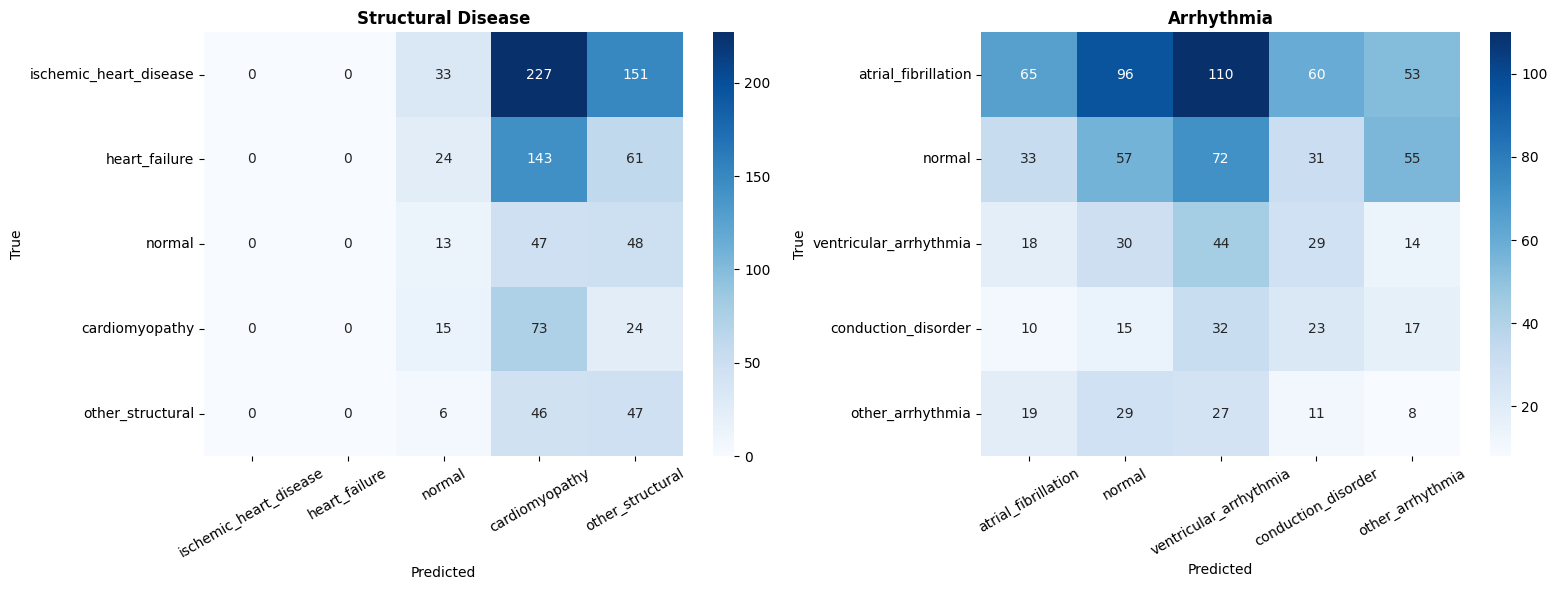

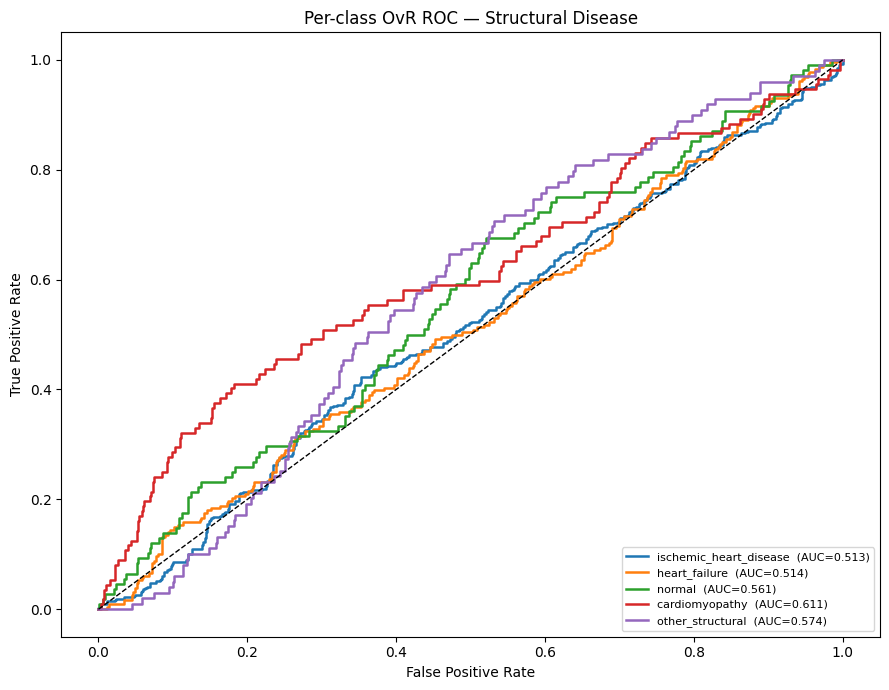

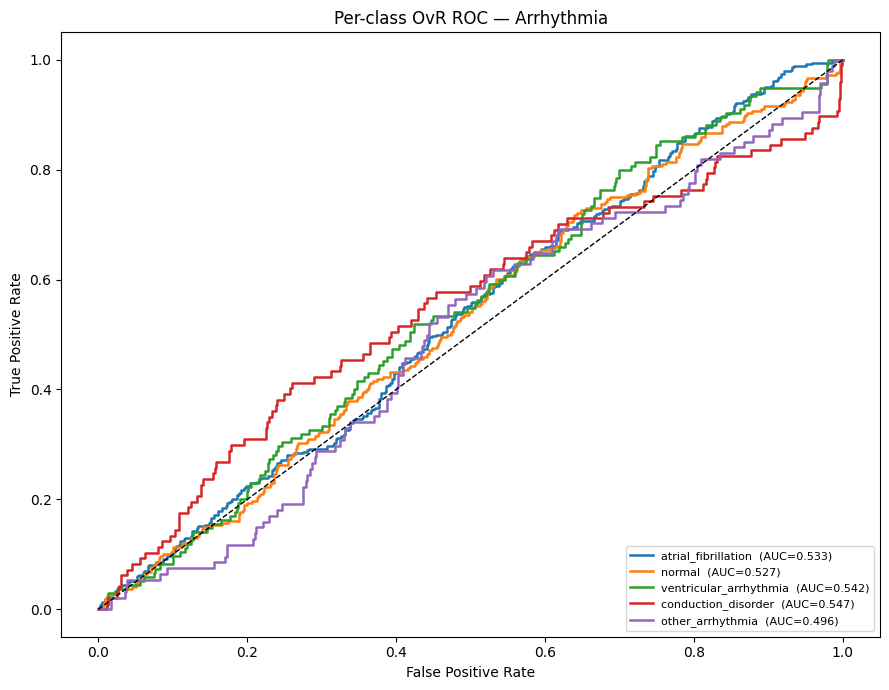


COMBINED SCORE  (structural + arrhythmia) / 2
  AUROC  : 0.5417
  AUPRC  : 0.2213
  Macro-F1 : 0.1519


In [ ]:
model.load_state_dict(torch.load(ckpt_best, map_location=DEVICE))
s_true, s_probs, a_true, a_probs = evaluate_mt(model, test_loader)

# Renormalise for float16 precision
s_probs = s_probs / s_probs.sum(axis=1, keepdims=True)
a_probs = a_probs / a_probs.sum(axis=1, keepdims=True)

s_preds = s_probs.argmax(-1)
a_preds = a_probs.argmax(-1)

s_auroc = roc_auc_score(s_true, s_probs, multi_class='ovr', average='macro')
a_auroc = roc_auc_score(a_true, a_probs, multi_class='ovr', average='macro')

from sklearn.preprocessing import label_binarize
s_bin = label_binarize(s_true, classes=list(range(NUM_CLASSES_STRUCT)))
a_bin = label_binarize(a_true, classes=list(range(NUM_CLASSES_ARR)))
s_auprc = average_precision_score(s_bin, s_probs, average='macro')
a_auprc = average_precision_score(a_bin, a_probs, average='macro')

s_f1 = f1_score(s_true, s_preds, average='macro', zero_division=0)
a_f1 = f1_score(a_true, a_preds, average='macro', zero_division=0)

print("=" * 70)
print("TEST SET RESULTS — Multi-Task Fusion Model  (5-class x 5-class)")
print("=" * 70)

print(f"\n--- STRUCTURAL DISEASE (5 classes) ---")
print(f"  AUROC (OvR macro) : {s_auroc:.4f}")
print(f"  AUPRC (macro)     : {s_auprc:.4f}")
print(f"  Macro-F1          : {s_f1:.4f}")
print(classification_report(s_true, s_preds, target_names=STRUCT_CLASSES, digits=3))

print(f"--- ARRHYTHMIA (5 classes) ---")
print(f"  AUROC (OvR macro) : {a_auroc:.4f}")
print(f"  AUPRC (macro)     : {a_auprc:.4f}")
print(f"  Macro-F1          : {a_f1:.4f}")
print(classification_report(a_true, a_preds, target_names=ARR_CLASSES, digits=3))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, true, preds, names, title in [
    (axes[0], s_true, s_preds, STRUCT_CLASSES, 'Structural Disease'),
    (axes[1], a_true, a_preds, ARR_CLASSES,    'Arrhythmia'),
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_multitask.png'), dpi=150)
plt.show()

# Per-class ROC curves
COLORS = plt.cm.tab10.colors
for task_name, true_b, probs, classes, fname in [
    ('Structural Disease', s_bin, s_probs, STRUCT_CLASSES, 'roc_structural'),
    ('Arrhythmia',         a_bin, a_probs, ARR_CLASSES,    'roc_arrhythmia'),
]:
    fig, ax = plt.subplots(figsize=(9, 7))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(true_b[:, i], probs[:, i])
        auc = roc_auc_score(true_b[:, i], probs[:, i])
        ax.plot(fpr, tpr, lw=1.8, color=COLORS[i % 10],
                label=f'{cls}  (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Per-class OvR ROC — {task_name}', fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{fname}.png'), dpi=150)
    plt.show()

print(f"\n{'='*70}")
print(f"COMBINED SCORE  (structural + arrhythmia) / 2")
print(f"  AUROC  : {(s_auroc + a_auroc) / 2:.4f}")
print(f"  AUPRC  : {(s_auprc + a_auprc) / 2:.4f}")
print(f"  Macro-F1 : {(s_f1 + a_f1) / 2:.4f}")
print(f"{'='*70}")

## 7 · XAI — Electromechanical Attribution Maps

Cross-attention weights from the last fusion layer + modality gate visualisation.

- **EAM heatmaps:** 3×3 ECG→Echo attention matrix per sample
- **Gate weights:** sigmoid gate values showing ECG vs Echo contribution per task

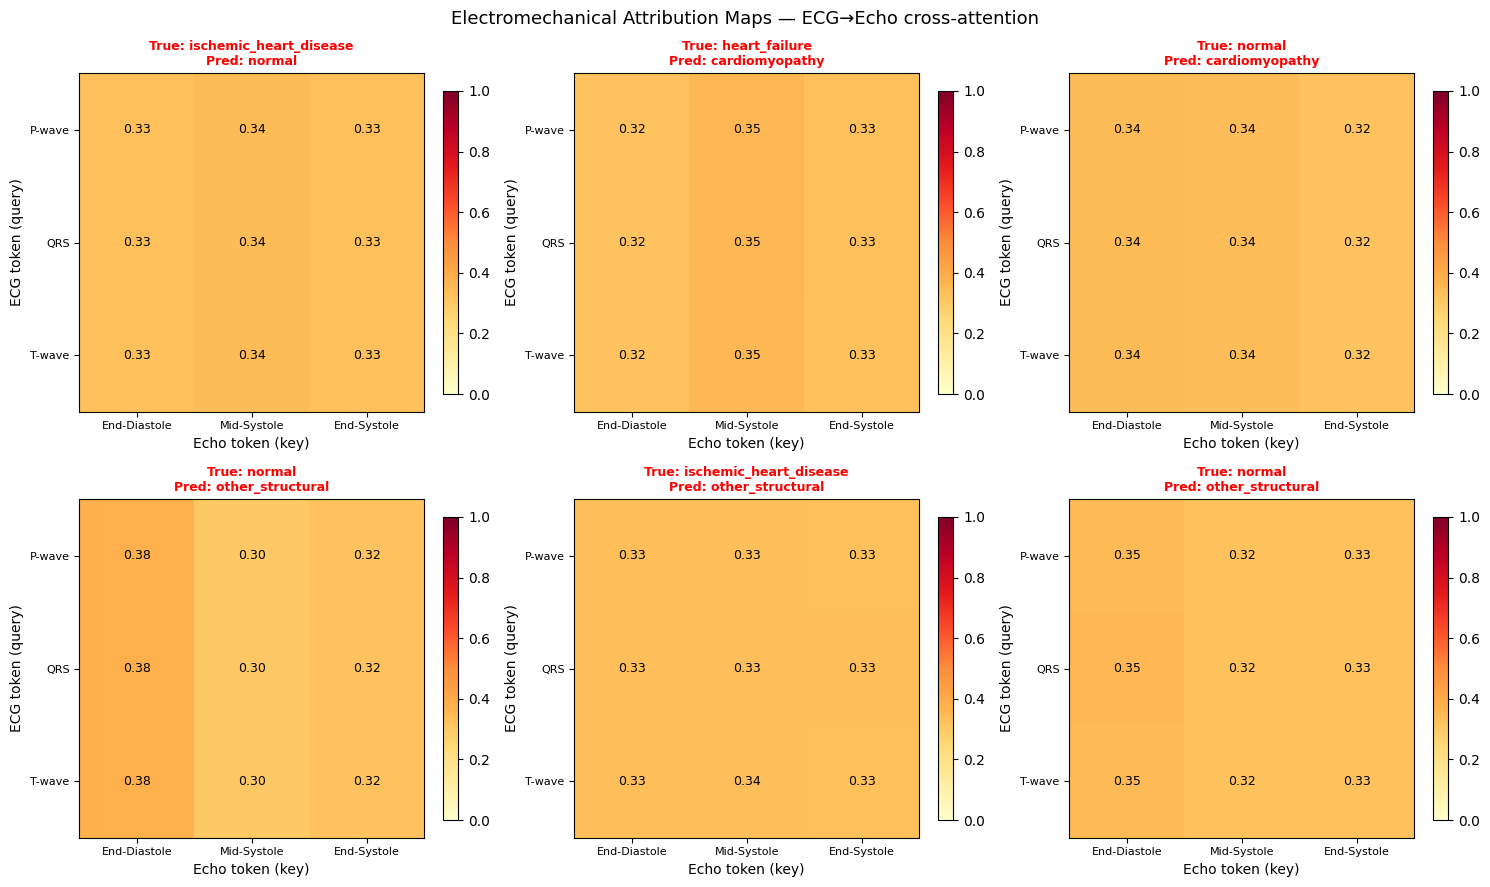

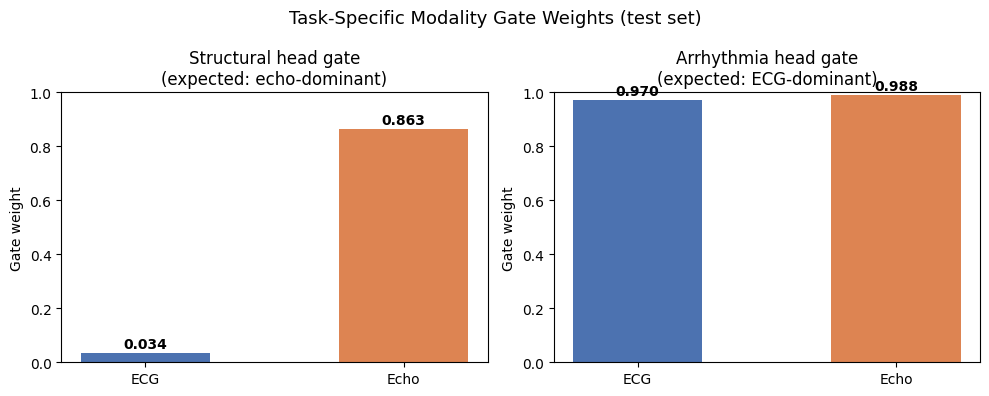

In [ ]:
ECG_TOK_NAMES  = ['P-wave', 'QRS', 'T-wave']
ECHO_TOK_NAMES = ['End-Diastole', 'Mid-Systole', 'End-Systole']

def plot_eam(model, loader, num_samples=6):
    model.eval()
    collected = []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for ecg, echo, labels, _ in loader:
            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    logits, _ = model(ecg.to(DEVICE), echo.to(DEVICE))
            else:
                logits, _ = model(ecg.to(DEVICE), echo.to(DEVICE))
            preds = logits.argmax(1).cpu()
            w = model.fusion.attn_weights['ecg_to_echo'].float()  # (B, 3, 3)
            for i in range(len(labels)):
                collected.append(dict(
                    attn    = w[i].numpy(),
                    true    = STRUCT_CLASSES[labels[i]],
                    pred    = STRUCT_CLASSES[preds[i]],
                    correct = (labels[i] == preds[i]).item()
                ))
            if len(collected) >= num_samples:
                break

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, s in zip(axes.flat, collected):
        im = ax.imshow(s['attn'], vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
        ax.set_xticks(range(3)); ax.set_xticklabels(ECHO_TOK_NAMES, fontsize=8)
        ax.set_yticks(range(3)); ax.set_yticklabels(ECG_TOK_NAMES,  fontsize=8)
        ax.set_xlabel('Echo token (key)');  ax.set_ylabel('ECG token (query)')
        color = 'green' if s['correct'] else 'red'
        ax.set_title(f"True: {s['true']}\nPred: {s['pred']}",
                     color=color, fontsize=9, fontweight='bold')
        for r in range(3):
            for c in range(3):
                ax.text(c, r, f"{s['attn'][r,c]:.2f}",
                        ha='center', va='center', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.04)

    plt.suptitle('Electromechanical Attribution Maps — ECG→Echo cross-attention', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'eam_samples.png'), dpi=150)
    plt.show()


plot_eam(model, test_loader, num_samples=6)

# ── Modality Gate Visualisation ──────────────────────────────────────────────
# Shows how much each task relies on ECG vs echo (averaged over the test set).
# ECG gate > echo gate for arrhythmia → correct asymmetry.
# Echo gate > ECG gate for structural  → correct asymmetry.

def plot_gates(model, loader, num_batches=5):
    model.eval()
    gs_list, ga_list = [], []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for i, (ecg, echo, _, _) in enumerate(loader):
            if i >= num_batches:
                break
            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    model(ecg.to(DEVICE), echo.to(DEVICE))
            else:
                model(ecg.to(DEVICE), echo.to(DEVICE))
            gs_list.append(model._g_struct.float().cpu())
            ga_list.append(model._g_arr.float().cpu())

    gs = torch.cat(gs_list).mean(0)  # [w_ecg, w_echo] for structural
    ga = torch.cat(ga_list).mean(0)  # [w_ecg, w_echo] for arrhythmia

    labels = ['ECG', 'Echo']
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, weights, title, expected in [
        (axes[0], gs, 'Structural head gate',  'echo-dominant'),
        (axes[1], ga, 'Arrhythmia head gate', 'ECG-dominant'),
    ]:
        bars = ax.bar(labels, weights.numpy(), color=['#4C72B0', '#DD8452'], width=0.5)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Gate weight')
        ax.set_title(f'{title}\n(expected: {expected})')
        for bar, v in zip(bars, weights):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                    f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    plt.suptitle('Task-Specific Modality Gate Weights (test set)', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gate_weights.png'), dpi=150)
    plt.show()

plot_gates(model, test_loader)


## 8 · Save Final Checkpoint

Saves model weights, 5-class label names, architecture config, and training history.

In [ ]:
final_path = os.path.join(OUTPUT_DIR, 'cardiac_fusion_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'struct_classes'  : STRUCT_CLASSES,
    'arr_classes'     : ARR_CLASSES,
    'config': dict(
        ecg_base_dim       = ECG_BASE_DIM,
        echo_base_dim      = ECHO_BASE_DIM,
        proj_dim           = PROJ_DIM,
        attn_heads         = ATTN_HEADS,
        attn_layers        = ATTN_LAYERS,
        ecg_seq_len        = ECG_SEQ_LEN,
        ecg_trans_layers   = ECG_TRANS_LAYERS,
        num_classes_struct = NUM_CLASSES_STRUCT,
        num_classes_arr    = NUM_CLASSES_ARR,
        lambda_struct      = LAMBDA_STRUCT,
        lambda_arr         = LAMBDA_ARR,
    ),
    'history': history,
}, final_path)

print(f"Saved: {final_path}")
print("\nAll output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1e6
    print(f"  {f:45s}  {mb:7.1f} MB")

Saved: C:\Users\anwme\Desktop\Datasets\model_output\cardiac_fusion_final.pt

All output files:
  binary_best.pt                                   110.5 MB
  cardiac_fusion_final.pt                          124.2 MB
  cm_Binary_Test_Set.png                             0.0 MB
  cm_Test_Set_Fusion_Model.png                       0.1 MB
  cm_multitask.png                                   0.1 MB
  eam_samples.png                                    0.1 MB
  gate_weights.png                                   0.0 MB
  history_Binary_EndToEnd.png                        0.1 MB
  history_MultiTask_EndToEnd.png                     0.1 MB
  history_Stage1_Frozen.png                          0.1 MB
  history_Stage2_FineTune.png                        0.0 MB
  history_ThreeStage_Curriculum.png                  0.1 MB
  multitask_best.pt                                124.2 MB
  roc_arrhythmia.png                                 0.1 MB
  roc_multitask.png                                  0.1 MB
  roc